In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_score

In [26]:
df = pd.read_csv(r"C:\Users\User\Desktop\water\data\cleaned_stats.csv")

In [67]:
features = [
    'conductivity_of_solution_ mS_cm',
    'oxidation_reduction_potential_ mV',
    'oxygen_saturation_%',
    'turbidity_NTU'
]

features2 = ['oxidation_reduction_potential_ mV','turbidity_NTU']

sensor_id_col = "sensor_id"
label_col = "Water_Quality_Label"

# Feature weights
weights = {
    'conductivity_of_solution_ mS_cm': 1,
    'oxidation_reduction_potential_ mV': 2,
    'oxygen_saturation_%': 0.8,
    'turbidity_NTU': 2
}

In [68]:
df_scaled = df.copy()

scaler = RobustScaler()

df_scaled[features] = scaler.fit_transform(
    df[features]
)


# Apply weights AFTER scaling
for feature, weight in weights.items():
    df_scaled[feature] *= weight

In [70]:
processed_sensor_dfs = []


for sensor in df_scaled[sensor_id_col].unique():

    sensor_mask = df_scaled[sensor_id_col] == sensor
    
    sensor_data = df_scaled.loc[
        sensor_mask, features
    ]

    original_sensor_data = df.loc[
        sensor_mask
    ].copy()


    if len(sensor_data) < 3:
        continue


    kmeans = KMeans(
        n_clusters=3,
        random_state=42,
        n_init=20
    )


    clusters = kmeans.fit_predict(sensor_data)


    original_sensor_data["cluster"] = clusters


    # Label clusters based on turbidity
    turbidity_order = (
        original_sensor_data
        .groupby("cluster")["turbidity_NTU"]
        .mean()
        .sort_values()
        .index
    )


    mapping = {
        turbidity_order[0]: "Ok",
        turbidity_order[1]: "Medium",
        turbidity_order[2]: "Danger"
    }


    original_sensor_data["Water_Quality_Label"] = (
        original_sensor_data["cluster"]
        .map(mapping)
    )


    original_sensor_data.drop(
        columns="cluster",
        inplace=True
    )


    processed_sensor_dfs.append(
        original_sensor_data
    )


final_training_df = pd.concat(
    processed_sensor_dfs
)

c:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [71]:
overall_stats = (
    final_training_df
    .groupby(label_col)[features]
    .agg(["mean", "median", "std"])
)

overall_stats

conductivity_of_solution_ mS_cm                           \
                                               mean     median           std   
Water_Quality_Label                                                            
Danger                                 51713.791471  55713.485   9268.095302   
Medium                                 50796.475461  54116.195  10620.923587   
Ok                                     54787.333996  56852.790   8899.979744   

                    oxidation_reduction_potential_ mV                       \
                                                 mean   median         std   
Water_Quality_Label                                                          
Danger                                     138.946539  137.810  143.992366   
Medium                                     155.709833  182.025  166.115045   
Ok                                         123.096688  198.005  178.809396   

                    oxygen_saturation_%                    turbidity_NTU  \
                                   mean  median        std          mean   
Water_Quality_Label                                                        
Danger                        71.026289  67.785  20.254517    423.115854   
Medium                        71.832088  68.125  17.785020    211.504328   
Ok                            73.448834  70.510  20.381725     89.446499   

                                          
                      median         std  
Water_Quality_Label                       
Danger               416.235  170.307323  
Medium               179.360  126.618298  
Ok                    44.510  104.604243

In [72]:
print("--- Overall Label Distribution ---")
print(final_training_df['Water_Quality_Label'].value_counts())

print("\n--- Feature Averages by Quality Label ---")
#profile_cols = [turbidity_col] + features_to_scale
print(final_training_df.groupby('Water_Quality_Label')[features].mean())

--- Overall Label Distribution ---
Water_Quality_Label
Medium    6484
Ok        4142
Danger    3196
Name: count, dtype: int64

--- Feature Averages by Quality Label ---
                     conductivity_of_solution_ mS_cm  \
Water_Quality_Label                                    
Danger                                  51713.791471   
Medium                                  50796.475461   
Ok                                      54787.333996   

                     oxidation_reduction_potential_ mV  oxygen_saturation_%  \
Water_Quality_Label                                                           
Danger                                      138.946539            71.026289   
Medium                                      155.709833            71.832088   
Ok                                          123.096688            73.448834   

                     turbidity_NTU  
Water_Quality_Label                 
Danger                  423.115854  
Medium                  211.504328  
Ok    

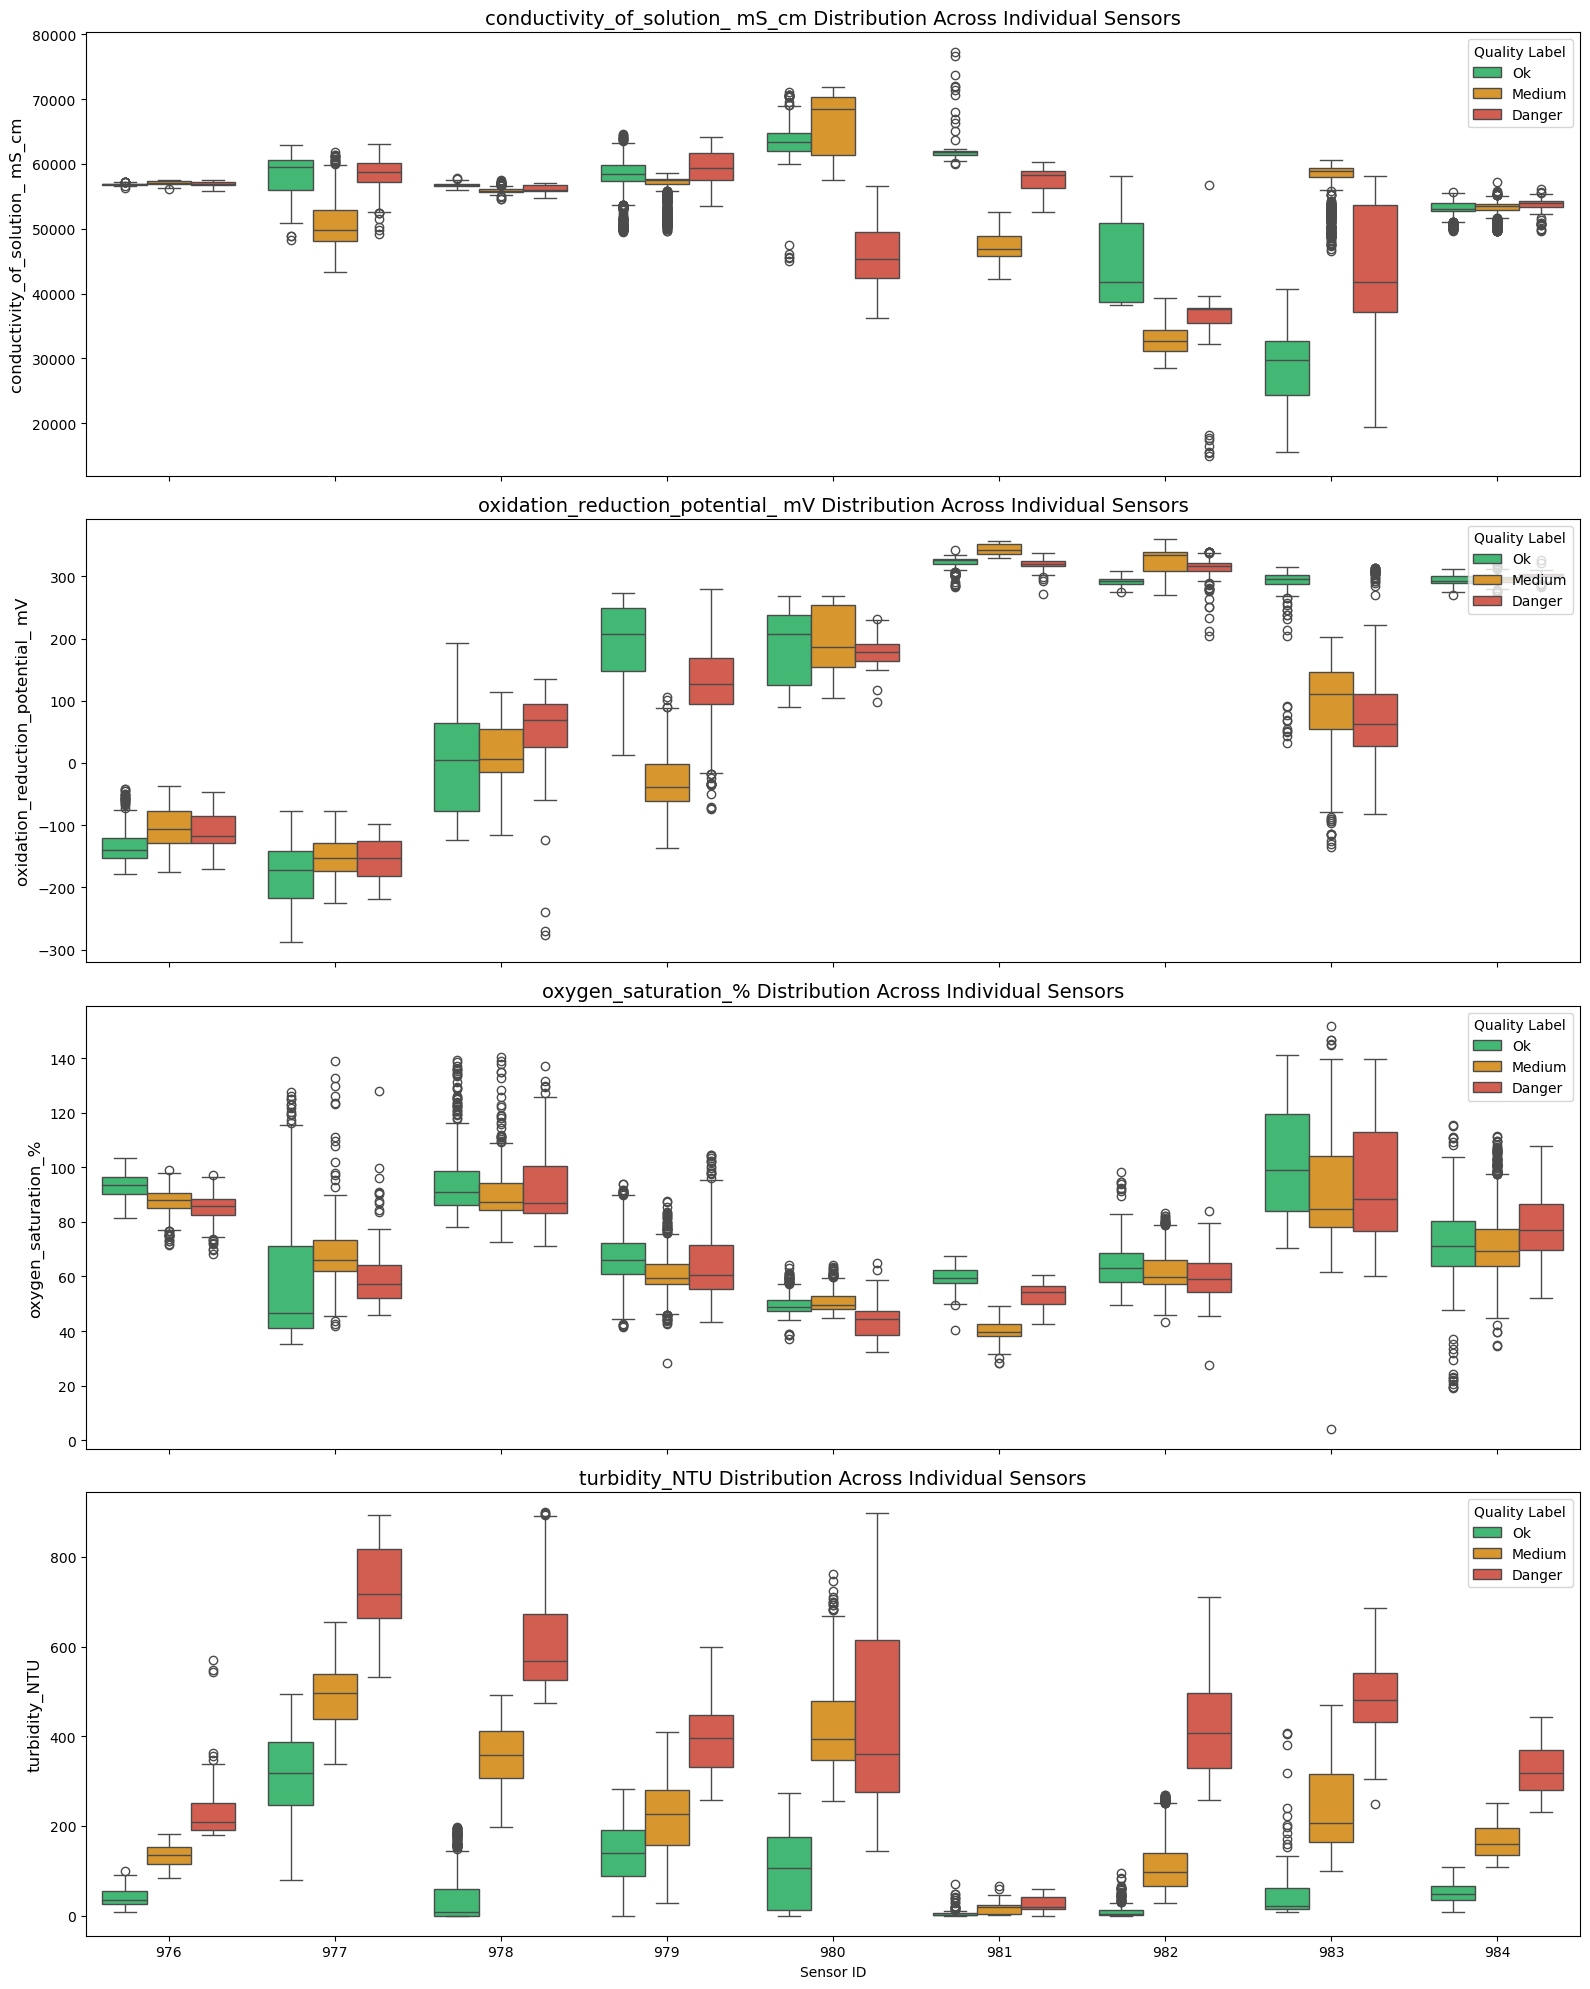

In [73]:
fig, axes = plt.subplots(4, 1, figsize=(16, 20), sharex=True)
label_order = ['Ok', 'Medium', 'Danger']
palette = {'Ok': '#2ecc71', 'Medium': '#f39c12', 'Danger': '#e74c3c'} # Green, Orange, Red
# Sort Sensor IDs so the X-axis stays consistently ordered
sensor_order = sorted(final_training_df['sensor_id'].unique())

for i, metric in enumerate(features):
    sns.boxplot(
        data=final_training_df,
        x='sensor_id',
        y=metric,
        hue='Water_Quality_Label',
        hue_order=label_order,
        palette=palette,
        order=sensor_order,
        ax=axes[i]
    )
    axes[i].set_title(f'{metric} Distribution Across Individual Sensors', fontsize=14)
    axes[i].set_xlabel('Sensor ID' if i == 3 else '') # Only show label on the bottom plot
    axes[i].set_ylabel(metric, fontsize=12)
    axes[i].legend(title='Quality Label', loc='upper right')

plt.tight_layout()
plt.show()

In [33]:
final_training_df.to_csv(r"C:\Users\User\Desktop\water\data\labeled_water_stats.csv")

In [66]:
df[df['sensor_id'] == 984].describe()

,Unnamed: 0,id,sensor_id,wtempV_°C,conductivity_of_solution_ mS_cm,oxidation_reduction_potential_ mV,total_suspended_solids_mg_L,turbidity_NTU,dissolved_oxygen_concentration _ppm,dissolved_oxygen_concentration_mg_L,oxygen_saturation_%,salinity_ppt,dissolved_solids _ppm
count,2194.000000,2194.000000,2194.0,2194.000000,2194.000000,2194.000000,2194.000000,2194.000000,2194.000000,2194.000000,2194.000000,2194.000000,2194.000000
mean,11166.387420,11167.387420,984.0,25.308163,53234.704521,295.814298,363.479717,159.850438,6.002434,6.002648,72.818865,35.151632,34713.273778
std,6431.108539,6431.108539,0.0,2.680443,1167.013104,6.786713,259.065151,89.830409,0.913809,0.913706,12.704581,0.886325,762.086292
min,10.000000,11.000000,984.0,19.430000,49657.880000,268.260000,13.240000,7.020000,1.760000,1.760000,19.210000,32.490000,32381.910000
25%,5242.250000,5243.250000,984.0,22.130000,52943.122500,291.240000,215.400000,110.330000,5.382500,5.390000,64.052500,34.910000,34524.212500
50%,11356.500000,11357.500000,984.0,25.365000,53471.380000,295.855000,287.725000,141.805000,5.950000,5.950000,70.660000,35.320000,34868.160000
75%,16984.000000,16985.000000,984.0,27.515000,53939.092500,300.447500,556.110000,194.190000,6.577500,6.577500,80.075000,35.690000,35172.912500
max,21268.000000,21269.000000,984.0,31.210000,57148.270000,326.120000,2827.660000,442.570000,9.570000,9.570000,115.450000,38.250000,37266.390000
